In [1]:
import matplotlib.pyplot as plt 
import numpy as np 
from matlabtools import Struct
from data_source import FW2DReader
import h5py 

def AngularAveragePSD(F, kx, ky, n_bins = 200):

    kn = (kx**2 + ky**2)**0.5
    k_min, k_max = kn.min(), kn.max()
    k_bins_edges = np.linspace(k_min, k_max, n_bins + 1)
    k_bins = 0.5 * (k_bins_edges[:-1] + k_bins_edges[1:])

    S = np.zeros(n_bins)
    counts = np.zeros(n_bins)

    kn_flat = kn.ravel()
    F_flat = F.ravel()

    # Digitize radial wavenumbers into bins
    inds = np.digitize(kn_flat, k_bins_edges)

    for i in range(1, n_bins + 1):
        mask = (inds == i)
        if np.any(mask):
            S[i-1] = np.mean(F_flat[mask])
            counts[i-1] = np.sum(mask)
        else:
            S[i-1] = 0

    return k_bins, S #* k_bins

def Spectrum(F, kx, ky):
    kn = (kx**2 + ky**2)**0.5
    k = kx[:int(kx.shape[0]/2),0]
    dk = kx[1,0]
    E = np.zeros(len(k))
    for i in range(len(k)):
        ring = np.where((kn>=k[i]-dk/2)&(kn<k[i]+dk/2)&(ky>0))
        E[i] =  2 * np.sum(F[ring]) + np.sum(F[i,0])
    # E = 2 * np.pi * k * E
    return k, E


### Advection ITG - TEM 1:0.5 (same omega)

/tmp/ipykernel_1831527/700213923.py:15: RuntimeWarning: invalid value encountered in divide
  ax.plot(ky*1e-2, (U0 + omega_ITG / ky ) /U0, '--b', alpha = 0.6)
/tmp/ipykernel_1831527/700213923.py:16: RuntimeWarning: invalid value encountered in divide
  ax.plot(ky*1e-2, (U0 + omega_TEM / ky ) /U0, '--g', alpha = 0.6)


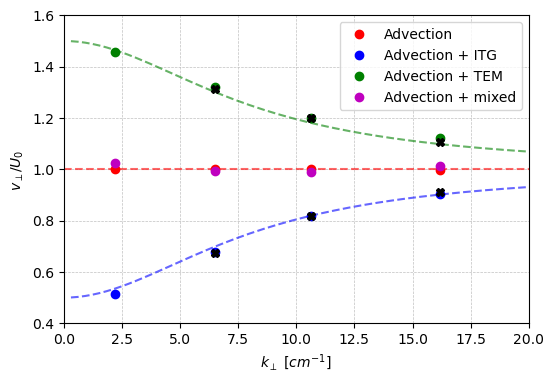

In [2]:
# Advection ITG TEM 

Nx, Ny, dx = 1024, 1024, 2e-4
dky = 2*np.pi / (Ny * dx)
ky = dky * np.r_[0:int(Ny/2 + 1)]
ky_c       = 0.8e3
omega0     = 5
omega_ITG = omega0 * ky / (1 + (ky / ky_c)**2)
omega_TEM = -omega0 * ky / (1 + (ky / ky_c)**2)
U0 = -10

fig, ax = plt.subplots(figsize = (6, 4))

ax.plot(ky*1e-2, U0 * np.ones_like(ky) /U0, '--r', alpha = 0.6)
ax.plot(ky*1e-2, (U0 + omega_ITG / ky ) /U0, '--b', alpha = 0.6)
ax.plot(ky*1e-2, (U0 + omega_TEM / ky ) /U0, '--g', alpha = 0.6)

FWS_advection = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/results/FWS_advection.mat')
FWS_advection_ITG = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/results/FWS_advection_ITG.mat')
FWS_advection_TEM = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/results/FWS_advection_TEM.mat')
FWS_advection_mixed = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/results/FWS_advection_mixed.mat')

ax.plot(FWS_advection.kp, FWS_advection.v_perp  /U0, 'or', label = 'Advection')
ax.plot(FWS_advection_ITG.kp, FWS_advection_ITG.v_perp/U0  , 'ob', label = 'Advection + ITG')
ax.plot(FWS_advection_TEM.kp, FWS_advection_TEM.v_perp /U0 , 'og', label = 'Advection + TEM')
ax.plot(FWS_advection_mixed.kp, FWS_advection_mixed.v_perp /U0 , 'om', label = 'Advection + mixed')
ax.plot(FWS_advection_mixed.kp, (2 * np.pi * np.array([np.nan, -1359, -2033, -2845])) / (FWS_advection_mixed.kp * 1e2) /U0 , 'Xk')
ax.plot(FWS_advection_mixed.kp, (2 * np.pi * np.array([np.nan, -697, -1386, -2349])) / (FWS_advection_mixed.kp * 1e2) /U0 , 'Xk')

ax.set_xlim(0, 20)
ax.set_ylim(0.4, 1.6)

ax.legend()
ax.grid(c = 'silver', ls = '--', lw = 0.5)
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$v_\perp / U_0$ ', fontsize = 10)
plt.show()

### Advection ITG - TEM 1:0.5 (different omega)

/tmp/ipykernel_1011651/2727080387.py:15: RuntimeWarning: invalid value encountered in divide
  ax.plot(ky*1e-2, (U0 + omega_ITG / ky ) /U0, '--b', alpha = 0.6)
/tmp/ipykernel_1011651/2727080387.py:16: RuntimeWarning: invalid value encountered in divide
  ax.plot(ky*1e-2, (U0 + omega_TEM / ky ) /U0, '--g', alpha = 0.6)
/tmp/ipykernel_1011651/2727080387.py:17: RuntimeWarning: invalid value encountered in divide
  ax.plot(ky*1e-2, (U0 + (omega_ITG + omega_TEM) / ky ) /U0, '--m', alpha = 0.6)


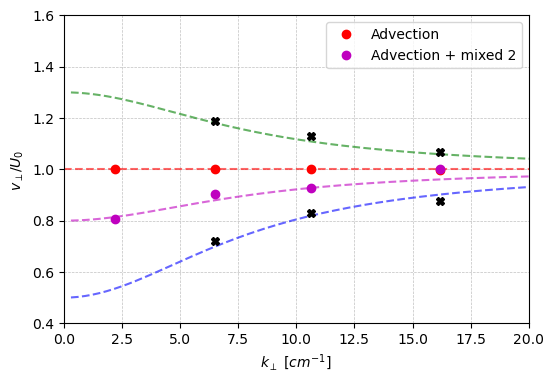

In [9]:
# Advection ITG TEM 

Nx, Ny, dx = 1024, 1024, 2e-4
dky = 2*np.pi / (Ny * dx)
ky = dky * np.r_[0:int(Ny/2 + 1)]
ky_c       = 0.8e3
omega0     = 5
omega_ITG = omega0 * ky / (1 + (ky / ky_c)**2)
omega_TEM = -3 * ky / (1 + (ky / ky_c)**2)
U0 = -10

fig, ax = plt.subplots(figsize = (6, 4))

ax.plot(ky*1e-2, U0 * np.ones_like(ky) /U0, '--r', alpha = 0.6)
ax.plot(ky*1e-2, (U0 + omega_ITG / ky ) /U0, '--b', alpha = 0.6)
ax.plot(ky*1e-2, (U0 + omega_TEM / ky ) /U0, '--g', alpha = 0.6)
ax.plot(ky*1e-2, (U0 + (omega_ITG + omega_TEM) / ky ) /U0, '--m', alpha = 0.6)

FWS_advection = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/results/FWS_advection.mat')
FWS_advection_ITG = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/results/FWS_advection_ITG.mat')
FWS_advection_TEM = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/results/FWS_advection_TEM.mat')
FWS_advection_mixed_2 = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/results/FWS_advection_mixed2.mat')

ax.plot(FWS_advection.kp, FWS_advection.v_perp  /U0, 'or', label = 'Advection')
# ax.plot(FWS_advection_ITG.kp, FWS_advection_ITG.v_perp/U0  , 'ob', label = 'Advection + ITG')
# ax.plot(FWS_advection_TEM.kp, FWS_advection_TEM.v_perp /U0 , 'og', label = 'Advection + TEM')
ax.plot(FWS_advection_mixed_2.kp, FWS_advection_mixed_2.v_perp /U0 , 'om', label = 'Advection + mixed 2')
ax.plot(FWS_advection_mixed_2.kp, (2 * np.pi * np.array([np.nan, -1231, -1911, -2750])) / (FWS_advection_mixed_2.kp * 1e2) /U0 , 'Xk') #-449
ax.plot(FWS_advection_mixed_2.kp, (2 * np.pi * np.array([np.nan, -747, -1404, -2260])) / (FWS_advection_mixed_2.kp * 1e2) /U0 , 'Xk') #-200

ax.set_xlim(0, 20)
ax.set_ylim(0.4, 1.6)
ax.legend()
ax.grid(c = 'silver', ls = '--', lw = 0.5)
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$v_\perp / U_0$ ', fontsize = 10)
plt.show()

### ITG - TEM 1:0.1 (sifferent omega)

/tmp/ipykernel_3772631/3105381992.py:15: RuntimeWarning: invalid value encountered in divide
  ax.plot(ky*1e-2 /2 , (U0 + omega_ITG / ky ) /U0, '--b', alpha = 0.6)
/tmp/ipykernel_3772631/3105381992.py:16: RuntimeWarning: invalid value encountered in divide
  ax.plot(ky*1e-2 /2 , (U0 + omega_TEM / ky ) /U0, '--g', alpha = 0.6)
/tmp/ipykernel_3772631/3105381992.py:17: RuntimeWarning: invalid value encountered in divide
  ax.plot(ky*1e-2 /2 , (U0 + (omega_ITG + omega_TEM) / ky ) /U0, '--m', alpha = 0.6)


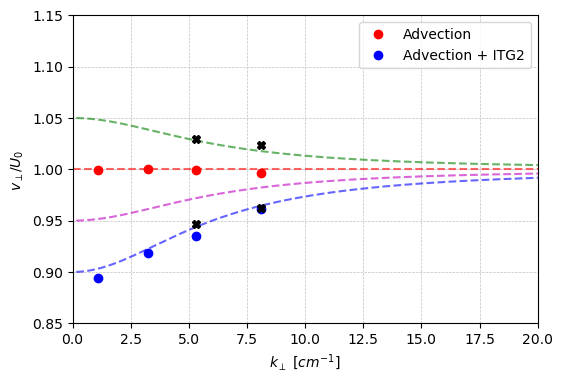

In [85]:
# Advection ITG TEM 

Nx, Ny, dx = 1024, 1024, 2e-4
dky = 2*np.pi / (Ny * dx)
ky = dky * np.r_[0:int(Ny/2 + 1)] 
ky_c       = 1.2e3
omega0     = 1
omega_ITG = omega0 * ky / (1 + (ky / ky_c)**2)
omega_TEM = -0.5 * ky / (1 + (ky / ky_c)**2)
U0 = -10

fig, ax = plt.subplots(figsize = (6, 4))

ax.plot(ky*1e-2 /2 , U0 * np.ones_like(ky) /U0, '--r', alpha = 0.6)
ax.plot(ky*1e-2 /2 , (U0 + omega_ITG / ky ) /U0, '--b', alpha = 0.6)
ax.plot(ky*1e-2 /2 , (U0 + omega_TEM / ky ) /U0, '--g', alpha = 0.6)
ax.plot(ky*1e-2 /2 , (U0 + (omega_ITG + omega_TEM) / ky ) /U0, '--m', alpha = 0.6)

FWS_advection = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/results/FWS_advection.mat')
FWS_advection_ITG_2 = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/results/FWS_advection_ITG_2.mat')
FWS_advection_TEM_3 = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/results/FWS_advection_TEM_3.mat')
FWS_advection_mixed_3 = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/results/FWS_advection_mixed_3.mat')

ax.plot(FWS_advection.kp / 2, FWS_advection.v_perp  * 1/U0, 'or', label = 'Advection')
ax.plot(FWS_advection_ITG_2.kp / 2, FWS_advection_ITG_2.v_perp *1/U0  , 'ob', label = 'Advection + ITG2')
# ax.plot(FWS_advection_TEM_3.kp / 2, FWS_advection_TEM_3.v_perp *1 /U0 , 'og', label = 'Advection + TEM3')
# ax.plot(FWS_advection_mixed_3.kp / 2, FWS_advection_mixed_3.v_perp *1 /U0 , 'om', label = 'Advection + mixed3')
ax.plot(FWS_advection_mixed_3.kp / 2, (2 * np.pi * np.array([np.nan, np.nan, -1742, -2634])) / (FWS_advection_mixed_3.kp * 1e2) /U0 , 'Xk') #-449
ax.plot(FWS_advection_mixed_3.kp / 2, (2 * np.pi * np.array([np.nan, np.nan, -1601, -2476])) / (FWS_advection_mixed_3.kp * 1e2) /U0 , 'Xk') #-200

ax.set_xlim(0, 20)
ax.set_ylim(0.85, 1.15)
ax.legend()
ax.grid(c = 'silver', ls = '--', lw = 0.5)
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$v_\perp / U_0$ ', fontsize = 10)
plt.show()

### ITG - TEM OG

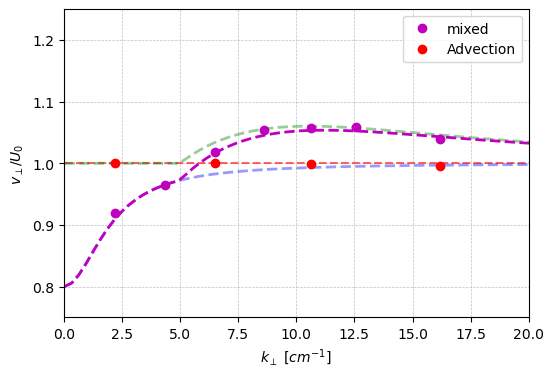

In [3]:
Nx, Ny = 1024, 1024
dx,dy=2e-4, 2e-4
Ly = dy * Ny
dky= 2*np.pi/Ly
kyl=np.r_[0.1:int(Ny/2+1)]*dky
k0I=0.2*1e3
k0T=1*1e3

Ti = 2
Te = 1.5
omega_ITG =  Ti * kyl / (1 + (kyl/(k0I ))**2)
omega_TEM = -Te* (kyl - k0T*0.5 ) / (1 + ((kyl - k0T*0.5 )/(k0T ))**2) * (kyl > 0.5 * k0T ) + np.zeros_like(kyl) * (kyl > 0.25 * k0T )
omega_eff_ky = 1.0 * omega_ITG + 1.0 * omega_TEM

U0 = -10
FWS_advection = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/_results/FWS_advection.mat')
FWS_mixed_advection = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/_results/FWS_mixed_advection.mat')

fig, ax = plt.subplots(figsize = (6, 4))

ax.plot(kyl*1e-2, U0 * np.ones_like(kyl) /U0, '--r', alpha = 0.6)

ax.plot(kyl *1e-2 , (U0 + omega_ITG / kyl) / U0,  '--', lw =2, c = 'b', alpha = 0.4, )
ax.plot(kyl *1e-2 , (U0 + omega_TEM / kyl) / U0,  '--', lw =2, c = 'g', alpha = 0.4, )

ax.plot(kyl *1e-2 , (U0 + omega_eff_ky / kyl) / U0,  '--', lw =2, c = 'm', )


ax.plot(FWS_mixed_advection.kp , FWS_mixed_advection.v_perp /U0, 'om' ,label = 'mixed')
ax.plot(FWS_advection.kp, FWS_advection.v_perp /U0, 'or' , label = 'Advection')
ax.set_xlim(0, 20)
ax.set_ylim(0.75, 1.25)
ax.legend()
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$v_\perp / U_0$ ', fontsize = 10)
ax.grid(c = 'silver', ls= '--', lw = 0.5)


In [4]:
Nx, Ny = 1024, 1024 # padded resolution
#Nx, Ny = 2 * int(np.floor(Npx/3)), 2 * int(np.floor(Npy/3)) # Fourier space resolution
# Lx, Ly = 32*np.pi, 32*np.pi #Size of the box, which sets the Fourier space resolution dkx, dky = 2*pi/Lx, 2*pi/Ly
dx,dy=2e-4, 2e-4
dt, Nt = 1e-4, 600
Lx, Ly = dx * Nx, dy * Ny
dkx,dky=2*np.pi/Lx, 2*np.pi/Ly
xl,yl=np.arange(0,Lx,dx),np.arange(0,Ly,dy)
x,y=np.meshgrid(xl,yl,indexing="ij")
kxl=np.r_[0.1:int(Nx/2),-int(Nx/2):-0.1]*dkx
kyl=np.r_[0.1:int(Ny/2+1)]*dky
kx,ky=np.meshgrid(kxl,kyl,indexing='ij')

# physics setting 
U0         = -10 * np.ones(Nx) # 4.0 
S          = 0 # -30  #-50
dt, Nt     = 1e-4, 600
phase      = np.exp(1j * 2 * np.pi * np.random.random(kx.shape) - np.pi)


a, b = 1, 2
thtI = -np.pi / 3
kperpI = np.sqrt((kx * np.cos(thtI) + ky * np.sin(thtI)) ** 2 / a ** 2+ (kx * np.sin(thtI) - ky * np.cos(thtI)) ** 2 / b ** 2)

kperp = np.sqrt(kx  ** 2 + ky ** 2 )
# kperp = kperpI

k0I=0.2*1e3
sigI=0.08*1e3
alpI= 3# 3.0
betI=1.0

AI= 1.0

k0T=1*1e3
sigT=0.2*1e3
alpT= 6# 6
betT=1.8
AT= 1


k2I = k0I / 2 * (1 + np.sqrt(1 + 4 * alpI * sigI**2 / k0I ** 2))
k1I = k0I / 2 * (1 + np.sqrt(1 - 4 * betI * sigI**2 / k0I ** 2))
BI = AI * np.exp(- (k2I - k0I) ** 2 / (2 * sigI ** 2)) * k2I ** alpI
CI = AI * np.exp(- (k1I - k0I) ** 2 / (2 * sigI ** 2)) * k1I ** (-betI)
fkI = AI * np.exp(- (kperpI - k0I) **2 / (2 * sigI **2)) * (kperpI < k2I) * (kperpI >= k1I) + BI * kperpI **(-alpI) * (kperpI >= k2I) + CI * kperpI ** betI * (kperpI < k1I)
nkI = fkI *  phase
nkI[-1:-int(Nx/2):-1,0]=nkI[1:int(Nx/2),0].conj()

k2T = k0T / 2 * (1 + np.sqrt(1 + 4 * alpT * sigT**2 / k0T ** 2))
k1T = k0T / 2 * (1 + np.sqrt(1 - 4 * betT * sigT**2 / k0T ** 2))
BT = AT * np.exp(- (k2T - k0T) ** 2 / (2 * sigT ** 2)) * k2T ** alpT
CT = AT * np.exp(- (k1T - k0T) ** 2 / (2 * sigT ** 2)) * k1T ** (-betT)
fkT = AT * np.exp(- (kperp - k0T) **2 / (2 * sigT **2)) * (kperp < k2T) * (kperp >= k1T) + BT * kperp **(-alpT) * (kperp >= k2T) + CT * kperp ** betT * (kperp < k1T)
nkT = fkT  * phase
nkT[-1:-int(Nx/2):-1,0]=nkT[1:int(Nx/2),0].conj()

fk = fkI + fkT
fk2 = 1 * fkI + 0.6 * fkT
fk3 = 1 * fkI + 0.4 * fkT
fk4 = 1 * fkI + 0.1 * fkT

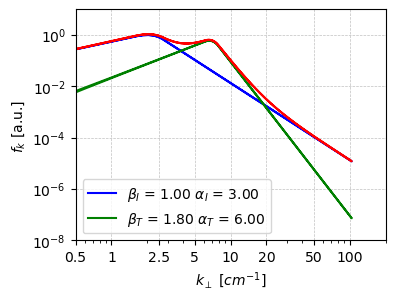

In [5]:
fig, ax = plt.subplots(1, 1, figsize = (4,3), sharex = True)

ax.loglog(kperpI[:,0] * 1e-2, fkI[:,0], c = 'b', label = r'$\beta_I$ = %.2f $\alpha_I$ = %.2f' %(betI, alpI))
ax.loglog(kperpI[:,0] * 1e-2, 0.6 * fkT[:,0], c = 'g', label = r'$\beta_T$ = %.2f $\alpha_T$ = %.2f' %(betT, alpT))
ax.loglog(kperpI[:,0] * 1e-2, fk2[:,0], c = 'r')

plt.subplots_adjust(hspace = 0)

ax.set_xlim(0.5, 200)
ax.set_ylim(1e-8, 10)
ax.legend(loc = 3)
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$f_k$ [a.u.] ', fontsize = 10)
ax.grid(c = 'silver', ls= '--', lw = 0.5)
ax.set_xticks([0.5, 1, 2.5, 5, 10, 20, 50, 100])
ax.set_xticklabels(["0.5", "1", "2.5", "5", "10", "20", "50", "100"])
plt.show()

In [6]:
i = 0
Pdiff = []
EL    = []
for angle in [5, 10, 15, 20, 25, 30, 40]:
    subdir = 'mixed_advection'
    simname = f'mixed_advection_f60_angle{angle}_RC_waist300'
    
    if angle == 40:
        rem_left = 50
        rem_right = 25
    elif angle == 20:
        rem_left = 25
        rem_right = 15
    else:
        rem_left = 1
        rem_right = 1
    spectra = FW2DReader.get_doppler_spectra(
            subdir, simname = simname, welch_spectra=False,
            save_results=False, load_if_existing=True,
            machine='irene', rem_left = rem_left, rem_right = rem_right
        )
    
    Pdiff.append(np.trapz(spectra.lorentian_fit, x=spectra.Freqs))
    EL.append(np.sum(spectra.lorentian_fit ) / 1024  / 1e-4)
    
FWS_mixed_advection.Pdiff = np.array(Pdiff)
FWS_mixed_advection.EL = np.array(EL)

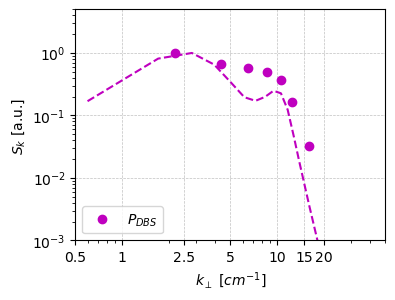

In [10]:
fig, ax = plt.subplots(figsize = (4, 3))
# _kx, _ky = np.meshgrid(_kxl, _kyl, indexing = 'ij')
ks, Sk = AngularAveragePSD(np.abs(fk3)**2, kx, ky)
ax.loglog(ks * 1e-2,( Sk ) / (Sk ).max(), '--m')
# Sk /= Sk.max()
# cond = (ks  *1e-2> 2.5) & (ks *1e-2 <= 10) 
# m, b = np.polyfit(np.log10(ks[cond]), np.log10(Sk[cond]), 1)
# print(m)
# ax.loglog(ks * 1e-2, 10 ** b * ks ** m , '--r', alpha = 0.5)

# cond = (ks  *1e-2> 13) & (ks *1e-2 <= 30)  
# m, b = np.polyfit(np.log10(ks[cond]), np.log10(Sk[cond]), 1)
# print(m)
# ax.loglog(ks * 1e-2, 10 ** b * ks ** m, '--b' , alpha = 0.5)


# cond = (FWS_mixed_advection.kp <= 10)  
# m, b = np.polyfit(np.log10(FWS_mixed_advection.kp[cond]), np.log10(FWS_mixed_advection.Pdiff[cond]), 1)
# print(m)
# ax.loglog(FWS_mixed_advection.kp[cond] , (10 ** b * FWS_mixed_advection.kp[cond] ** m) / FWS_mixed_advection.Pdiff.max(), '-g' , label = r'$\alpha$ = %.2f' %m)

# cond = (FWS_mixed_advection.kp > 10)  
# m, b = np.polyfit(np.log10(FWS_mixed_advection.kp[cond]), np.log10(FWS_mixed_advection.Pdiff[cond]), 1)
# print(m)
# ax.loglog(FWS_mixed_advection.kp[cond] , (10 ** b * FWS_mixed_advection.kp[cond] ** m) / FWS_mixed_advection.Pdiff.max(), '-k' , label = r'$\alpha$ = %.2f' %m)
ax.loglog(FWS_mixed_advection.kp, FWS_mixed_advection.Pdiff / FWS_mixed_advection.Pdiff.max(), 'om', label = r'$P_{DBS}$')


ax.set_xlim(0.5, 50)
ax.set_ylim(1e-3, 5)
ax.legend(loc = 3)
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$S_{k}$ [a.u.] ', fontsize = 10)
ax.set_xticks([ 0.5, 1, 2.5, 5, 10, 15, 20])
ax.set_xticklabels([ "0.5", "1", "2.5", "5", "10", "15", "20"])
ax.grid(c = 'silver', ls= '--', lw = 0.5)
plt.show()

1.5078138882164198
-0.7848074585284129
-10.436338135122988
-6.114362565832834


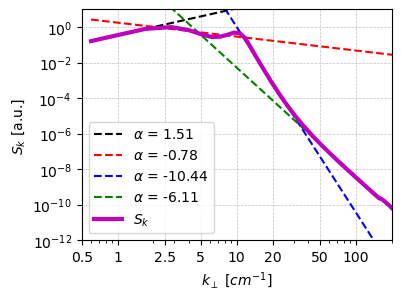

In [35]:
fig, ax = plt.subplots(figsize = (4,3))

cond = (ks  *1e-2 <= 2.5) 
m, b = np.polyfit(np.log10(ks[cond]), np.log10(Sk[cond]), 1)
print(m)
ax.loglog(ks * 1e-2, 10 ** b * ks ** m , '--k', label = r'$\alpha$ = %.2f' %m)

cond = (ks  *1e-2> 2.5) & (ks *1e-2 <= 10) 
m, b = np.polyfit(np.log10(ks[cond]), np.log10(Sk[cond]), 1)
print(m)
ax.loglog(ks * 1e-2, 10 ** b * ks ** m , '--r', label = r'$\alpha$ = %.2f' %m)

cond = (ks  *1e-2> 12) & (ks *1e-2 <= 30)  
m, b = np.polyfit(np.log10(ks[cond]), np.log10(Sk[cond]), 1)
print(m)
ax.loglog(ks * 1e-2, 10 ** b * ks ** m, '--b' , label = r'$\alpha$ = %.2f' %m)

cond = (ks  *1e-2> 30) 
m, b = np.polyfit(np.log10(ks[cond]), np.log10(Sk[cond]), 1)
print(m)
ax.loglog(ks * 1e-2, 10 ** b * ks ** m, '--g' , label = r'$\alpha$ = %.2f' %m)

ax.loglog(ks * 1e-2, Sk, '-m', lw = 3, label = r'$S_k$')

ax.set_xlim(0.5, 200)
ax.set_ylim(1e-12, 10)
ax.legend(loc = 3)
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$S_k$ [a.u.] ', fontsize = 10)
ax.grid(c = 'silver', ls= '--', lw = 0.5)
ax.set_xticks([ 0.5, 1, 2.5, 5, 10, 20, 50, 100])
ax.set_xticklabels([ "0.5", "1", "2.5", "5", "10", "20", "50", "100"])
plt.show()

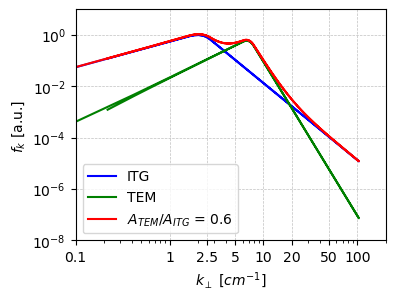

In [171]:
fig, ax = plt.subplots(figsize = (4, 3))

ax.loglog(kperpI[:,0] * 1e-2, fkI[:,0], 'b', label = 'ITG', )
ax.loglog(kperpI[:,0] * 1e-2, 0.6 * fkT[:,0], 'g', label = 'TEM',)
ax.loglog(kperpI[:,0] * 1e-2, (fkI + 0.6 * fkT)[:,0], 'r', label = r'$A_{TEM} / A_{ITG}$ = 0.6')

ax.set_xlim(0.1, 200)
ax.set_ylim(1e-8, 10)
ax.legend(loc = 3)
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$f_k$ [a.u.] ', fontsize = 10)
ax.grid(c = 'silver', ls= '--', lw = 0.5)
ax.set_xticks([ 0.1, 1, 2.5, 5, 10, 20, 50, 100])
ax.set_xticklabels([ "0.1", "1", "2.5", "5", "10", "20", "50", "100"])
plt.show()

### ITG - TEM final version

file /home/FO278650/Bureau/FullWave2D_FO/data/maps/advection_ITG_TEM.h5 read


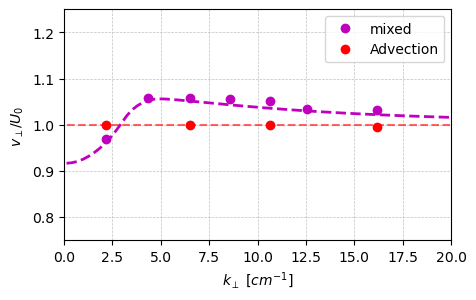

In [4]:
#Advection ITG TEM last 
import h5py

output_file = '/home/FO278650/Bureau/FullWave2D_FO/data/maps/advection_ITG_TEM.h5'
with h5py.File(output_file, "r") as f:
    # n_txky = f['fields/n'][:]
    # omega  = f['profiles/omega_ky'][:]
    # ky         = f['grid/ky'][:]
    omega_ITG = f['profiles/omega_ITG'][:]
    omega_TEM = f['profiles/omega_TEM'][:]
    omega_ky = f['profiles/omega_ky'][:]
    kx        = f['grid/kx'][:]
    ky        = f['grid/ky'][:]
    fkI       = f['spectrum/fkI'][:]
    fkT       = f['spectrum/fkT'][:]
    U0        = f.attrs['U0']
    rhos      = f.attrs['rhos']
    AI        = f.attrs['AI']
    AT        = f.attrs['AT']

f.close()
print(f'file {output_file} read')

_kyl = ky / rhos
_kxl = kx / rhos

U0 = -10
FWS_advection = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/_results/FWS_advection.mat')
FWS_mixed_advection_2 = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/_results/FWS_mixed_advection_2.mat')

fig, ax = plt.subplots(figsize = (5, 3))

ax.plot(_kyl*1e-2, U0 * np.ones_like(_kyl) /U0, '--r', alpha = 0.6)
ax.plot(_kyl *1e-2 , (U0 + omega_ky / _kyl) / U0,  '--', lw =2, c = 'm', )

ax.plot(FWS_mixed_advection_2.kp  , FWS_mixed_advection_2.v_perp /U0, 'om' ,label = 'mixed')
ax.plot(FWS_advection.kp , FWS_advection.v_perp /U0, 'or' , label = 'Advection')

ax.set_xlim(0, 20)
ax.set_ylim(0.75, 1.25)
ax.legend()
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$v_\perp / U_0$ ', fontsize = 10)
ax.grid(c = 'silver', ls= '--', lw = 0.5)
plt.show()


In [5]:
i = 0
Pdiff = []
EL    = []
for angle in [5, 10, 15, 20, 25, 30, 40]:
    subdir = 'mixed_advection_2'
    simname = f'mixed_advection_2_f60_angle{angle}_RC_waist300'
    
    if angle == 40:
        rem_left = 100
        rem_right = 30
    elif (angle == 25) or (angle == 30):
        rem_left = 50
        rem_right = 15
    elif (angle == 10) or (angle == 15):
        rem_left = 25
        rem_right = 15
    else:
        rem_left = 1
        rem_right = 1
    spectra = FW2DReader.get_doppler_spectra(
            subdir, simname = simname, welch_spectra=False,
            save_results=False, load_if_existing=True,
            machine='irene', rem_left = rem_left, rem_right = rem_right
        )
    
    Pdiff.append(np.trapz(spectra.lorentian_fit, x=spectra.Freqs))
    EL.append(np.sum(spectra.lorentian_fit ) / 1024  / 1e-4)
    
FWS_mixed_advection_2.Pdiff = np.array(Pdiff)
FWS_mixed_advection_2.EL = np.array(EL)

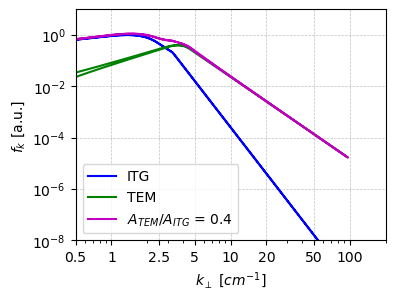

In [6]:
fig, ax = plt.subplots(figsize = (4, 3))

_kx, _ky = np.meshgrid(kx / rhos, ky / rhos, indexing = 'ij')

a, b = 1, 2
thtI = -np.pi / 3
kperpI = np.sqrt((_kx * np.cos(thtI) + _ky * np.sin(thtI)) ** 2 / a ** 2+ (_kx * np.sin(thtI) - _ky * np.cos(thtI)) ** 2 / b ** 2)

ax.loglog(kperpI[:,0] * 1e-2, AI *fkI[:,0], c = 'b', label = 'ITG')
ax.loglog(kperpI[:,0] * 1e-2, AT *fkT[:,0], c = 'g', label = 'TEM')
ax.loglog(kperpI[:,0] * 1e-2, AI *fkI[:,0] + AT *fkT[:,0], c = 'm', label = r'$A_{TEM} / A_{ITG}$ = %.1f' %AT)

ax.set_xlim(0.5, 200)
ax.set_ylim(1e-8, 10)
ax.legend(loc = 3)
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$f_k$ [a.u.] ', fontsize = 10)
ax.grid(c = 'silver', ls= '--', lw = 0.5)
ax.set_xticks([0.5, 1, 2.5, 5, 10, 20, 50, 100])
ax.set_xticklabels(["0.5", "1", "2.5", "5", "10", "20", "50", "100"])
plt.show()

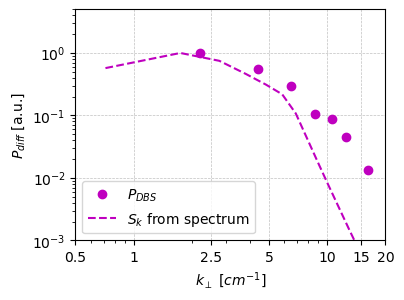

In [9]:
fig, ax = plt.subplots(figsize = (4,3))
_kx, _ky = np.meshgrid(_kxl, _kyl, indexing = 'ij')
ks, Sk = AngularAveragePSD(np.abs(AI * fkI + AT * fkT)**2, _kx, _ky)
ax.loglog(FWS_mixed_advection_2.kp, FWS_mixed_advection_2.Pdiff / FWS_mixed_advection_2.Pdiff.max(), 'om', label = r'$P_{DBS}$')
ax.loglog(ks * 1e-2,( Sk ) / (Sk ).max(), '--m', label = r'$S_k$ from spectrum')

# cond = (FWS_mixed_advection_2.kp <= 10)  
# m, b = np.polyfit(np.log10(FWS_mixed_advection_2.kp[cond]), np.log10(FWS_mixed_advection_2.Pdiff[cond]), 1)
# print(m)
# ax.loglog(FWS_mixed_advection_2.kp[cond] , (10 ** b * FWS_mixed_advection_2.kp[cond] ** m) / FWS_mixed_advection_2.Pdiff.max(), '-g' , label = r'$\alpha$ = %.2f' %m)

# cond = (FWS_mixed_advection_2.kp > 10)  
# m, b = np.polyfit(np.log10(FWS_mixed_advection_2.kp[cond]), np.log10(FWS_mixed_advection_2.Pdiff[cond]), 1)
# print(m)
# ax.loglog(FWS_mixed_advection_2.kp[cond] , (10 ** b * FWS_mixed_advection_2.kp[cond] ** m) / FWS_mixed_advection_2.Pdiff.max(), '-k' , label = r'$\alpha$ = %.2f' %m)

ax.set_xlim(0.5, 20)
ax.set_ylim(1e-3, 5)
ax.legend(loc = 3)
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$P_{diff}$ [a.u.] ', fontsize = 10)
ax.grid(c = 'silver', ls= '--', lw = 0.5)
ax.set_xticks([ 0.5, 1, 2.5, 5, 10, 15, 20])
ax.set_xticklabels([ "0.5", "1", "2.5", "5", "10", "15", "20"])
plt.show()

-1.5786427745598264
-6.418304621648597


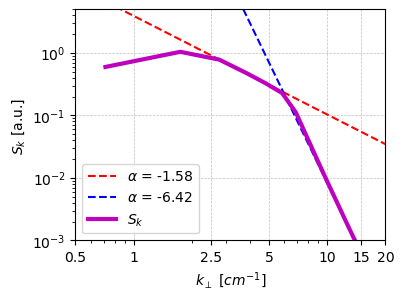

In [53]:
fig, ax = plt.subplots(figsize = (4,3))

cond = (ks  *1e-2> 2.5) & (ks *1e-2 <= 5) 
m, b = np.polyfit(np.log10(ks[cond]), np.log10(Sk[cond]), 1)
print(m)
ax.loglog(ks * 1e-2, 10 ** b * ks ** m , '--r', label = r'$\alpha$ = %.2f' %m)

cond = (ks  *1e-2> 5) 
m, b = np.polyfit(np.log10(ks[cond]), np.log10(Sk[cond]), 1)
print(m)
ax.loglog(ks * 1e-2, 10 ** b * ks ** m, '--b' , label = r'$\alpha$ = %.2f' %m)

ax.loglog(ks * 1e-2, Sk, '-m', lw = 3, label = r'$S_k$')

ax.set_xlim(0.5, 20)
ax.set_ylim(1e-3, 5)
ax.legend(loc = 3)
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$S_k$ [a.u.] ', fontsize = 10)
ax.grid(c = 'silver', ls= '--', lw = 0.5)
ax.set_xticks([ 0.5, 1, 2.5, 5, 10, 15, 20])
ax.set_xticklabels([ "0.5", "1", "2.5", "5", "10", "15", "20"])
plt.show()

### Cyclone base case

file /home/FO278650/Bureau/FullWave2D_FO/data/maps/gene/advection_cyclonbase.h5 read


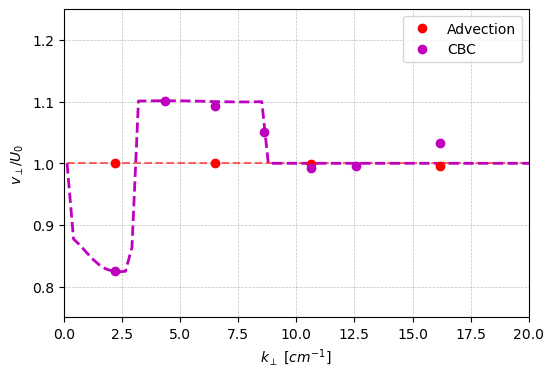

In [54]:
import h5py

output_file = '/home/FO278650/Bureau/FullWave2D_FO/data/maps/gene/advection_cyclonbase.h5'
with h5py.File(output_file, "r") as f:
    # n_txky = f['fields/n'][:]
    # omega  = f['profiles/omega_ky'][:]
    # ky         = f['grid/ky'][:]
    # omega_ITG = f['profiles/omega_ITG'][:]
    # omega_TEM = f['profiles/omega_TEM'][:]
    omega_ky = f['profiles/omega_ky'][:]
    kx        = f['grid/kx'][:]
    ky        = f['grid/ky'][:]
    # fkI       = f['spectrum/fkI'][:]
    # fkT       = f['spectrum/fkT'][:]
    fk        = f['spectrum/fk'][:]
    U0        = f.attrs['U0']
    rhos      = f.attrs['rhos']
    # # AI        = f.attrs['AI']
    # AT        = f.attrs['AT']

f.close()
print(f'file {output_file} read')


_kyl = ky / rhos

U0 = -10
FWS_advection = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/results/FWS_advection.mat')
FWS_cyclonbase = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/results/FWS_cyclonbase.mat')


fig, ax = plt.subplots(figsize = (6, 4))

ax.plot(_kyl*1e-2, U0 * np.ones_like(_kyl) /U0, '--r', alpha = 0.6)
ax.plot(_kyl *1e-2 , (U0 + omega_ky / _kyl) / U0,  '--', lw =2, c = 'm', )


ax.plot(FWS_advection.kp , FWS_advection.v_perp /U0, 'or' , label = 'Advection')
ax.plot(FWS_cyclonbase.kp  , FWS_cyclonbase.v_perp /U0, 'om' ,label = 'CBC')

ax.set_xlim(0, 20)
ax.set_ylim(0.75, 1.25)
ax.legend()
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$v_\perp / U_0$ ', fontsize = 10)
ax.grid(c = 'silver', ls= '--', lw = 0.5)